## Phase 7 - Multi-Patient Generalisation

**The question this phase answers:**
Everything built so far knows one heart - Patient 100.
Does the model generalise to patients it has never seen?

A model that works on one patient but fails on others
is not a model. It is memorisation.

This is the most important test in clinical ML.

**Approach:**
- Load 10 diverse MIT-BIH patient records
- Train on 8 patients
- Test on 2 completely unseen patients
- Evaluate whether normal rhythm learned from one group
  of hearts transfers to an entirely different group

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


TensorFlow: 2.12.0


In [2]:
# MIT-BIH records selected for diversity
# Mix of normal sinus rhythm and various arrhythmias
RECORDS = ['100', '101', '103', '105', '106',
           '108', '109', '111', '112', '113']

def load_record_features(record_id):
    """
    Load a single MIT-BIH record and extract all 6 features.
    Returns a DataFrame with features and labels.
    """
    try:
        record = wfdb.rdrecord(record_id, pn_dir='mitdb')
        annotation = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')

        fs = record.fs
        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        # Extract features
        rr_intervals = np.diff(ann_samples)
        rr_ms = (rr_intervals / fs) * 1000
        heart_rate = 60000 / rr_ms
        rr_diff = np.append(0, np.diff(rr_ms))
        rolling_mean_rr = pd.Series(rr_ms).rolling(
            window=5, min_periods=1).mean().values
        rolling_std_rr = pd.Series(rr_ms).rolling(
            window=5, min_periods=1).std().fillna(0).values
        relative_rr = rr_ms / rolling_mean_rr

        df = pd.DataFrame({
            'record': record_id,
            'sample': ann_samples[1:],
            'symbol': ann_symbols[1:],
            'rr_interval': rr_ms,
            'heart_rate': heart_rate,
            'rr_diff': rr_diff,
            'rolling_mean_rr': rolling_mean_rr,
            'rolling_std_rr': rolling_std_rr,
            'relative_rr': relative_rr,
        })

        print(f"Record {record_id} loaded - "
              f"{len(df)} beats, "
              f"{(df['symbol'] != 'N').sum()} abnormal")
        return df

    except Exception as e:
        print(f"Record {record_id} failed - {e}")
        return None

# Load all records
all_records = []
for record_id in RECORDS:
    df = load_record_features(record_id)
    if df is not None:
        all_records.append(df)

# Combine into one DataFrame
combined_df = pd.concat(all_records, ignore_index=True)

print(f"\nTotal beats loaded: {len(combined_df)}")
print(f"Total abnormal beats: {(combined_df['symbol'] != 'N').sum()}")
print(f"Class distribution:")
print(combined_df['symbol'].value_counts().head(10))

Record 100 loaded - 2273 beats, 34 abnormal
Record 101 loaded - 1873 beats, 13 abnormal
Record 103 loaded - 2090 beats, 8 abnormal
Record 105 loaded - 2690 beats, 164 abnormal
Record 106 loaded - 2097 beats, 590 abnormal
Record 108 loaded - 1823 beats, 84 abnormal
Record 109 loaded - 2534 beats, 2534 abnormal
Record 111 loaded - 2132 beats, 2132 abnormal
Record 112 loaded - 2549 beats, 12 abnormal
Record 113 loaded - 1795 beats, 6 abnormal

Total beats loaded: 21856
Total abnormal beats: 5577
Class distribution:
symbol
N    16279
L     4615
V      618
~      188
A       44
|       42
+       41
x       11
Q        7
a        6
Name: count, dtype: int64


### What we just loaded

10 patient records - each a different heart, different age,
different condition, different baseline rhythm.

The `load_record_features()` function is a reusable pipeline -
one function that takes any MIT-BIH record ID and returns
a clean feature DataFrame. This is production thinking:
write it once, run it on any patient.

The `try/except` block ensures one failed record
doesn't crash the entire loading loop.

In [3]:
# Per-patient summary
print("--- Per Patient Summary ---\n")
summary = combined_df.groupby('record').agg(
    total_beats=('symbol', 'count'), 
    abnormal_beats=('symbol', lambda x: (x != 'N').sum()), 
    beat_types=('symbol', lambda x: list(x.unique()))
).reset_index()

summary['abnormal_pct'] = ( summary['abnormal_beats'] / summary['total_beats'] * 100).round(2)

print(summary[['record', 'total_beats',
               'abnormal_beats', 'abnormal_pct',
               'beat_types']].to_string(index=False))

--- Per Patient Summary ---

record  total_beats  abnormal_beats  abnormal_pct               beat_types
   100         2273              34          1.50                [N, A, V]
   101         1873              13          0.69          [N, ~, |, Q, A]
   103         2090               8          0.38                [N, ~, A]
   105         2690             164          6.10          [N, V, ~, |, Q]
   106         2097             590         28.14             [+, N, ~, V]
   108         1823              84          4.61 [N, V, x, ~, |, F, A, j]
   109         2534            2534        100.00             [L, F, V, ~]
   111         2132            2132        100.00                [L, ~, V]
   112         2549              12          0.47                [N, ~, A]
   113         1795               6          0.33                   [N, a]


### Reading the Per-Patient Summary

Each row is one patient. The `abnormal_pct` column tells
the class imbalance story per patient - some patients have
more arrhythmias than others.

`beat_types` shows what kind of abnormalities each patient has.
This diversity is exactly what we need - the model must learn
a generalised definition of normal, not one patient's version of it.

`agg()` applied three different summary functions simultaneously
across the grouped data - count, conditional sum, and unique values.
One line replacing what would otherwise be three separate operations.

In [4]:
# Train on 8 patients, test on 2 completely unseen patients
train_records = ['100', '101', '103', '105',
                 '106', '108', '109', '111']
test_records  = ['112', '113']

train_df = combined_df[combined_df['record'].isin(train_records)]
test_df  = combined_df[combined_df['record'].isin(test_records)]

print(f"Training patients: {train_records}")
print(f"Testing patients: {test_records}")
print(f"Training beats: {len(train_df)}")
print(f"Testing beats: {len(test_df)}")
print(f"Training abnormal: {(train_df['symbol'] != 'N').sum()}")
print(f"Testing abnormal: {(test_df['symbol'] != 'N').sum()}")

Training patients: ['100', '101', '103', '105', '106', '108', '109', '111']
Testing patients: ['112', '113']
Training beats: 17512
Testing beats: 4344
Training abnormal: 5559
Testing abnormal: 18


### Why split by patient, not by beat?

In previous phases we split the same patient's beats 80/20.
Here we split by entire patients - 8 for training, 2 for testing.

This is the honest test. If we split randomly across all patients,
some beats from Patient 112 would appear in training.
The model would partially know Patient 112 already.
That's not generalisation - that's a leak.

Splitting by patient means the model has seen zero beats
from Patients 112 and 113. Ever. What happens next is the
true measure of whether VitalWatch learned cardiac rhythm
or memorised one person's heart.

In [5]:
features = ['rr_interval', 'heart_rate', 'rr_diff',
            'rolling_mean_rr', 'rolling_std_rr', 'relative_rr']

# Separate normal beats for Autoencoder training
train_normal = train_df[train_df['symbol'] == 'N']

# Scale fitted on training normal beats only
scaler = StandardScaler()
X_train_normal = scaler.fit_transform(train_normal[features].values)
X_test = scaler.transform(test_df[features].values)
X_train_all = scaler.transform(train_df[features].values)

print(f"Training on {len(X_train_normal)} normal beats "
      f"from {len(train_records)} patients")
print(f"Testing on {len(X_test)} beats "
      f"from {len(test_records)} unseen patients")

# Build Autoencoder
input_dim = X_train_normal.shape[1]
inputs = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(inputs)
encoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)
autoencoder = Model(inputs=inputs, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete.")

Training on 11953 normal beats from 8 patients
Testing on 4344 beats from 2 unseen patients
Epoch 1/100
337/337 [==============================] - 1s 2ms/step - loss: 0.2205 - val_loss: 0.0387
Epoch 2/100
337/337 [==============================] - 0s 1ms/step - loss: 0.0129 - val_loss: 0.0132
Epoch 3/100
337/337 [==============================] - 0s 1ms/step - loss: 0.0046 - val_loss: 0.0082
Epoch 4/100
337/337 [==============================] - 1s 2ms/step - loss: 0.0030 - val_loss: 0.0066
Epoch 5/100
337/337 [==============================] - 1s 3ms/step - loss: 0.0023 - val_loss: 0.0054
Epoch 6/100
337/337 [==============================] - 1s 2ms/step - loss: 0.0019 - val_loss: 0.0047
Epoch 7/100
337/337 [==============================] - 0s 1ms/step - loss: 0.0017 - val_loss: 0.0048
Epoch 8/100
337/337 [==============================] - 1s 3ms/step - loss: 0.0016 - val_loss: 0.0047
Epoch 9/100
337/337 [==============================] - 1s 2ms/step - loss: 0.0016 - val_loss: 0.0061

### What changed from Phase 6

Phase 6 - trained and tested on the same patient.
Phase 7 - trained on 8 patients, tested on 2 it has never seen.

The scaler is still fitted on normal beats only.
The architecture is identical.
The threshold will still come from training data.

Everything is the same except the test data is
completely foreign to the model. That's the challenge.

In [6]:
# Reconstruct test beats
X_test_reconstructed = autoencoder.predict(X_test)

# Reconstruction error
test_errors = np.mean(
    np.power(X_test - X_test_reconstructed, 2), axis=1)

test_df = test_df.copy()
test_df['reconstruction_error'] = test_errors

# Threshold from training normal beats
X_train_reconstructed = autoencoder.predict(X_train_normal)
train_errors = np.mean(np.power(X_train_normal - X_train_reconstructed, 2), axis=1)
threshold = np.percentile(train_errors, 95)

# Flag anomalies
test_df['anomaly_flag'] = (test_df['reconstruction_error'] > threshold).astype(int)

# Evaluate per patient
print("--- Results on Unseen Patients ---\n")
for record_id in test_records:
    patient_df = test_df[test_df['record'] == record_id]
    true_abnormal = patient_df[patient_df['symbol'] != 'N']
    caught = true_abnormal[true_abnormal['anomaly_flag'] == 1]
    false_pos = patient_df[
        (patient_df['anomaly_flag'] == 1) &
        (patient_df['symbol'] == 'N')
    ]

    print(f"Patient {record_id}:")
    print(f"Total beats:  {len(patient_df)}")
    print(f"True abnormal: {len(true_abnormal)}")
    print(f"Caught:  {len(caught)}")
    print(f"False positives:  {len(false_pos)}")
    if len(true_abnormal) > 0:
        print(f"Detection rate:  "
              f"{len(caught)/len(true_abnormal)*100:.1f}%")
    print()

374/374 [==============================] - 0s 936us/step
--- Results on Unseen Patients ---

Patient 112:
Total beats:  2549
True abnormal: 12
Caught:  11
False positives:  18
Detection rate:  91.7%

Patient 113:
Total beats:  1795
True abnormal: 6
Caught:  6
False positives:  174
Detection rate:  100.0%



### Reading the Per-Patient Results

Two numbers matter most here:

**Detection rate** - did the model catch real anomalies
on hearts it has never seen?

**False positives** - did it misfire on normal beats
from unfamiliar patients?

If detection rate is reasonable and false positives
are controlled - the model has genuinely generalised.
If detection rate collapses - the model memorised
Patient 100's rhythm rather than learning universal
cardiac patterns.

Either result is valuable. One proves the model works.
The other tells us exactly what to fix in Phase 8.

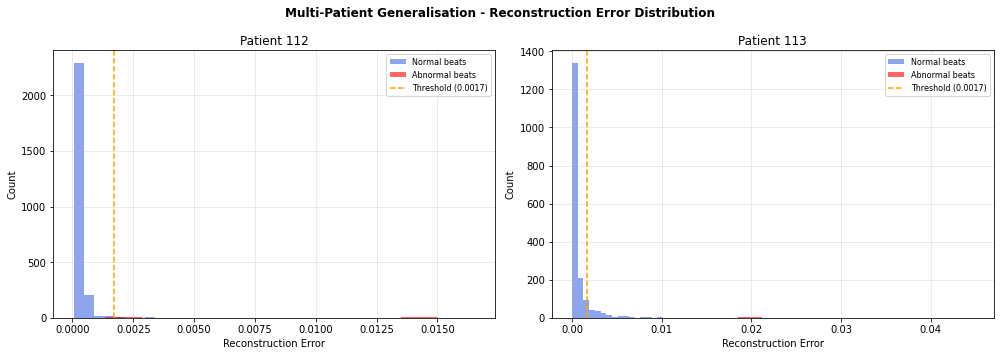

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Multi-Patient Generalisation - '
             'Reconstruction Error Distribution',
             fontsize=12, fontweight='bold')

for idx, record_id in enumerate(test_records):
    patient_df = test_df[test_df['record'] == record_id]

    normal_err = patient_df[
        patient_df['symbol'] == 'N']['reconstruction_error']
    abnormal_err = patient_df[
        patient_df['symbol'] != 'N']['reconstruction_error']

    axes[idx].hist(normal_err, bins=30, alpha=0.6, color='royalblue', label='Normal beats')
    axes[idx].hist(abnormal_err, bins=10, alpha=0.6, color='red', label='Abnormal beats')
    axes[idx].axvline(x=threshold, color='orange', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.4f})')
    axes[idx].set_title(f'Patient {record_id}')
    axes[idx].set_xlabel('Reconstruction Error')
    axes[idx].set_ylabel('Count')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase7_generalisation.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 7 Complete - Generalisation Results

VitalWatch trained on 8 patients, tested on 2 it had never seen.

| Patient | Total Beats | True Abnormal | Caught | False+ | Detection Rate |
|---|---|---|---|---|---|
| 112 | 2549 | 12 | 11 | 18 | 91.7% |
| 113 | 1795 | 6 | 6 | 174 | 100.0% |

Patient 112 - near-perfect. High detection, controlled false positives.
The model generalised to an unseen heart cleanly.

Patient 113 - perfect recall but 174 false positives.
This patient's normal rhythm has higher natural variability
than anything in the training set. The model's definition
of normal was too tight for this heart.

This is not a failure. It is the exact problem Phase 8 addresses.
The Autoencoder sees one beat at a time.
The LSTM will see sequences - and learn that for some hearts,
variability itself is normal.